# Time-resolved EPR simulation of photoexcited triplet states with reverse intersystem crossing

This notebook constructs a complete relaxation model for a molecular spin system of singlet and triplet states (both charge-transfer (CT) and locally-excited (LE) triplets).  
The work is organized into connected sections:

1. **Spin sample construction** – creating singlet, triplet LE, and triplet CT states.
2. **Relaxation pathway definition** – building decay and exchange mechanisms.
3. **Spectral simulation** – calculating time-resolved spectra.
4. **Parameter analysis** – investigating temperature and orientation dependence of relaxation rate

We strongly recommend that you first review Example 1, then Example 5, and then begin working with this notebook.

\
\
\
\
\
\
For any questions, please contact Arkady Samsonenko via: \
Telegram: @Arkady_Samsonenko \
Email: a.samsonenko.tomo.nsc.ru\
\
\
The last notebook update: 2026.08.01

We import necessary libraries and set the computational backend (CPU, double precision). Experimental parameters (microwave frequency, temperature) are defined early.

In [45]:
import sys
import os
import typing as tp
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

#Delite this line if you installed MaRs.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

# Import Mars library components
import mars
from mars import spin_model, spectra_manager, mesher, constants
from mars import utils
from mars import population

# # Let's import some useful functions for plotting simulation results over time.
from mars import visualization

In [46]:
dtype = torch.float64
device = torch.device("cpu")

# We set the experimental parameters here i the beggining:
freq_res = 35 * 1e9  # 35 GHz
temperature = torch.tensor(150.0, dtype=dtype, device=device)

# 1. Spin Sample Construction

We define a function get_samples that creates three spin samples (singlet, triplet LE, triplet CT) and a concatenated sample that combines them in a block‑diagonal Hamiltonian

All samples are SolidSample objects that will later be evaluated over an orientation mesh.

In [47]:
def get_samples(mesh: mars.mesher.BaseMesh) -> tp.Tuple[
    mars.spin_model.SolidSample,
    mars.spin_model.SolidSample,
    mars.spin_model.SolidSample,
    mars.spin_model.SolidSample]:
    """
    Create all spin samples used in the simulation.

    :param mesh : mars.mesher.Mesh
        Orientation mesh over which the sample is defined.
    :return: tuple of the next objects
        singlet : SolidSample
            Singlet (S=0) sample.
        triplet_LE : SolidSample
            Triplet (S=1) sample for the locally‑excited state.
        triplet_CT : SolidSample
            Triplet (S=1) sample for the charge‑transfer state.
        concated_sample : SolidSample
            Block‑diagonal concatenation of CT, LE, and singlet samples.
    """
    
    g_tensor = spin_model.Interaction([2.00, 2.00, 2.00], dtype=dtype, device=device)
    
    # Singlet (S=0) – isotropic g-tensor, energy shift 0.2 eV
    base_spin_system = spin_model.SpinSystem(
        electrons=[0.0],  # S=0 singlet
        g_tensors=[g_tensor],
        energy_shift=constants.unit_converter(0.2, "eV_to_Hz"),
        device=device,
        dtype=dtype,
    )

    singlet = spin_model.SolidSample(
        base_spin_system=base_spin_system,
        ham_strain=0.0,
        gauss=0.00025,
        lorentz=0.00025,
        mesh=mesh,
        device=device,
        dtype=dtype,
    )

    # Triplet LE (S=1) – anisotropic g, ZFS parameters D=2 GHz, E=0.3 GHz. Energy shift is 0.1eV
    g_tensor = spin_model.Interaction([2.00, 2.01, 2.02], dtype=dtype, device=device)
    zfs_interaction = spin_model.DEInteraction([2e9, 0.3e9], dtype=dtype, device=device)  # 2000 and 300 MHz

    base_spin_system = spin_model.SpinSystem(
        electrons=[1.0],  # S=1 triplet
        g_tensors=[g_tensor],
        electron_electron=[(0, 0, zfs_interaction)],
        energy_shift=constants.unit_converter(0.1, "eV_to_Hz"),
        device=device,
        dtype=dtype,
    )

    triplet_le = spin_model.SolidSample(
        base_spin_system=base_spin_system,
        ham_strain=0.0,
        gauss=0.00025,
        lorentz=0.00025,
        mesh=mesh,
        device=device,
        dtype=dtype,
    )
    
    # Triplet CT (S=1) – smaller ZFS D=0.4 GHz, E=0.05 GHz
    g_tensor = spin_model.Interaction([2.00, 2.01, 2.02], dtype=dtype, device=device)
    zfs_interaction = spin_model.DEInteraction([0.4e9, 0.05e9], dtype=dtype, device=device)  # 400 and 50 MHz
    base_spin_system = spin_model.SpinSystem(
        electrons=[1.0],  # S=1 triplet
        g_tensors=[g_tensor],
        electron_electron=[(0, 0, zfs_interaction)],
        device=device,
        dtype=dtype
    )
    
    triplet_ct = spin_model.SolidSample(
        base_spin_system=base_spin_system,
        ham_strain=0.0,
        gauss=0.00025,
        lorentz=0.00025,
        mesh=mesh,
        device=device,
        dtype=dtype,
    )

    # Concatenate CT, LE, singlet (block‑diagonal)
    concated_sample = mars.concat((triplet_ct, triplet_le, singlet))
    return singlet, triplet_le, triplet_ct, concated_sample

In [48]:
mesh = mesher.DelaunayMesh(interpolate=True, dtype=dtype, device=device)
singlet, triplet_le, triplet_ct, full_sample = get_samples(mesh)

D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\spin_model.py:1493: UserWarning: A spin-0 electron creates a singlet-state system. g-tensors are not physically meaningful for this system.
  warnings.warn(
D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\spin_model.py:304: UserWarning: You are creating a block-diagonal (non-interacting) composite spin system via direct sum. This does NOT represent a true multi-particle quantum system (which would require a tensor-product space). Only use this if you are modeling effectively isolated subsystems (e.g., for polarized or time-resolved EPR). For physical spin clusters (diradicals, etc.), build a single SpinSystem with explicit couplings instead.
  concatenated_spin_system = concat_spin_systems(spin_systems)
D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\spin_model.py:2459: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather

In this example, MaRs issues several warnings regarding the physical validity of the concatenation process. 

The underlying message is simple: "Proceed with this approach *only* if you understand the physical validity of what you are doing."

# 2. Relaxation Pathways

The relaxation model consists of four contributions:

1) Singlet decay – population decay of the singlet state.

2) Triplet decay – population decay of each triplet sublevel (in the xyz basis).

3) Intra‑triplet relaxation – Redfield relaxation among the triplet sublevels, driven by librational motions.

4) Singlet–triplet and triplet-triplet exchange – population transfer between singlet and triplet sublevels (both CT and LE), and between CT and LE triplets.

### 2.1. Set the singlet and triplet decay and their population

In [49]:
def get_decay_contexts(singlet, triplet_le, triplet_ct):
    """
    Create decay contexts for singlet and triplet states.

    :param singlet: Singlet sample.
    :param triplet_le: LE triplet sample.
    :param triplet_ct: CT triplet sample.
    :return: Singlet decay (rate 1e7 s^-1),
    LE triplet decay (rate 1e3 s^-1 per sublevel, xyz basis), CT triplet decay (rate 1e3 s^-1 per sublevel, xyz basis).
    """
    # We do not nessusary need to set basis here, since it has only one state
    ctx_singlet = population.Context(init_populations=[1.0], decay_rates=[1e7], device=device, dtype=dtype) # We set the decay in 1e7 s^-1
    
    # Herein we already need basis "xyz" and samples which set this basis
    ctx_le_decay = population.Context(basis="xyz", sample=triplet_le, decay_rates=[1e3, 1e3, 1e3], device=device, dtype=dtype)
    ctx_ct_decay = population.Context(basis="xyz", sample=triplet_ct, decay_rates=[1e3, 1e3, 1e3], device=device, dtype=dtype)
    
    return ctx_singlet, ctx_le_decay, ctx_ct_decay

In [50]:
ctx_singlet, ctx_le_decay, ctx_ct_decay = get_decay_contexts(singlet, triplet_le, triplet_ct)

### 2.2. Set the Intra-tiplet relaxation

We implement a spectral density function that models the coupling to a bath of librational modes. The coupling operators are derived from the sample's librations along the molecular axes.

#### 2.2.1. Set spectral Density Class

The SpectralDensity class computes the spectral density J(w) at a given temperature. It uses a Lorentzian broadening whose width depends on temperature through the Bose–Einstein occupation.

In [51]:
import math
import typing as tp
import torch
# from ... import constants  # Ensure your imports are correct

class SpectralDensity:
    """
    Calculates the Spectral Density function based on a set of mode frequencies 
    and temperature, utilizing a Lorentzian broadening model.
    
    Spectral density for a set of harmonic modes with Lorentzian broadening.

    For each mode k with frequency ω_k (in cm^-1), the spectral density at probe
    frequency ω (rad/s) and temperature T is:
        J(ω) = Σ_k [ δ/(δ^2 + (ω_k+ω)^2) * n(ω_k) + δ/(δ^2 + (ω_k-ω)^2) * (n(ω_k)+1) ]
    where n(ω_k) = 1/(exp(ħω_k/k_B T) - 1) and δ = sqrt(ω_k^2 * exp(ħω_k/k_B T) * n^2)
    (the broadening is chosen to preserve detailed balance).
    
    """

    def __init__(self, w_k: tp.Union[float, torch.Tensor],
                 dtype: torch.dtype = torch.float32, device: torch.device = torch.device("cpu")):
        """
        Initialize the SpectralDensity calculator.

        :param w_k: Mode frequencies in inverse centimeters (cm^-1).
        :param dtype: Data type for floating point operations.
        :param device: Computation device.
        """
        super().__init__()
        w_k_hz = constants.unit_converter(w_k, "cm-1_to_Hz")
        self.w_k_rad = torch.tensor(w_k_hz, dtype=dtype, device=device) * (2 * math.pi)
        
        # Store the temperature-independent energy conversion for use in __call__
        self.w_k_K = torch.tensor(constants.unit_converter(w_k, "cm-1_to_K"), dtype=dtype, device=device)

    def __call__(self, w_rad: tp.Union[torch.Tensor, float], temperature: tp.Union[float, torch.Tensor]) -> torch.Tensor:
        """
        Evaluate the spectral density at given probe frequencies and temperature.

        :param w_rad: Probe frequencies in radians per second (rad/s).
        :param temperature: System temperature in Kelvin.
        :return: Spectral density values calculated at the probe frequencies.
        """
        # Calculate temperature-dependent terms dynamically
        x = self.w_k_K / temperature
        exp_val = torch.exp(x)
        occup = 1.0 / torch.expm1(x)
        
        # Calculate the broadening parameter (delta)
        delta = torch.sqrt(self.w_k_rad ** 2 * exp_val * occup ** 2)

        plus = self.w_k_rad + w_rad
        minus = self.w_k_rad - w_rad
        
        term_plus = self._lorentz(plus, delta) * occup
        term_minus = self._lorentz(minus, delta) * (occup + 1.0)
        
        return term_plus + term_minus

    def _lorentz(self, arg: torch.Tensor, delta: torch.Tensor) -> torch.Tensor:
        """
        Compute the Lorentzian lineshape function.

        :param arg: Frequency argument (typically sum or difference of frequencies).
        :param delta: Broadening parameter (depends on temperature).
        :return: Lorentzian value delta / (delta^2 + arg^2).
        """
        return delta / (delta ** 2 + arg ** 2)

    def __repr__(self) -> str:
        """
        Return a string representation of the object.

        :return: String containing class name and shape of mode frequencies.
        """
        return f"SpectralDensity(modes={self.w_k_rad.shape}, device={self.w_k_rad.device})"

#### 2.2.2 Get coupling operators

In the current consideration we get the coupling operators via the librations along x,y,z axes. Each libration happens with each own frequency.

In the general the final coupling operaotor in MaRs is constructed from two parts:
 
- O_static: Field-independent operator. This is zero-field splitting and hyperfine interaction
- O_dependent: Field-dependent operator. This is zero-field Zeeman interaction

MaRs can automatically extract it. Thay are mesured in Hz and Hz / T respectifully. We need to convert Hz into rad / s  

In [52]:
def get_copling_operators(triplet):
    """
    Extract coupling operators for librations along the x, y, z axes.

    For each axis, we obtain the static and field‑dependent operators (in Hz)
    and convert them to rad/s.

    :param triplet: Triplet sample for which to compute the operators.
    :return: List of tuples, each containing (O_static_rad, O_field_rad) for one axis.
    """
    coupling_operators = []
    for i in range(3):
        n = torch.zeros((3, ), dtype=dtype, device=device)
        n[i] = 1.0
        O_static, O_field = triplet.get_librations_along_axis(n)
        O_static = O_static * (2 * math.pi)
        O_field = O_field * (2 * math.pi)
        coupling_operators.append(
            (O_static, O_field)
        )
    return coupling_operators

#### 2.2.3 Set final intra-triplet context

We create a Redfield relaxation channel for each librational mode (here we use three modes, one per axis, each at 100 cm^-1). The RedfieldRelaxationChannel takes the coupling operators and the spectral density function.

In [53]:
def get_context_triplet_intra(freq, triplet):
    """
    Build a context for intra‑triplet Redfield relaxation.

    :param freq: Mode frequencies in cm⁻¹ for each axis.
    :param triplet: Triplet sample.
    :return: Relaxation context for intra‑triplet processes.
    """
    coupling_operators = get_copling_operators(triplet)
    channels = []
    
    for i, freq in enumerate(frequencies):
        spectral_density_func = SpectralDensity(freq, dtype, device)
        channels.append(
            population.RedfieldRelaxationChannel(operator_components=[coupling_operators[i]],
                                                 spectral_density_func=spectral_density_func,
                                                 thermal_balance_mode="skip")  # The thermal balans is already set in spectral function
        )

    context_triplet_intra = population.Context(
        basis="product", sample=triplet,
        relaxation_coupling_channels=channels, device=device, dtype=dtype
    )
    return context_triplet_intra

In [54]:
frequencies = [100, 100, 100]

ctx_le_intra = get_context_triplet_intra(frequencies, triplet_le)
ctx_ct_intra = get_context_triplet_intra(frequencies, triplet_ct)

We can check the intra‑triplet relaxation rates at a given field and temperature.

In [55]:
fields = torch.tensor([0.3])
F, _, _, Gz = triplet_le.get_hamiltonian_terms()
H = F + Gz * fields
H  = H.unsqueeze(-3)
energies, full_system_vectors = torch.linalg.eigh(H)

# For the Redfield relaxation the driven probs return the rates, not free. It is supposed that thay shouldn't be modified futher
rates = ctx_le_intra.get_transformed_driven_rates(full_system_vectors, fields=fields.unsqueeze(-2), energies=energies, temperature=temperature)
print(rates[0, 0])    # rate matrix in eigenbasis

tensor([[       0.0000,  8968594.4893,   848150.1838],
        [ 8951366.3915,        0.0000, 10299996.3591],
        [  843893.7505, 10268029.6529,        0.0000]], dtype=torch.float64)


### 2.3. Set the rates between singlet and triplet sublevels

We define rates between singlet and each triplet sublevel (in the xyz basis) and between CT and LE triplets. Since the concatenated sample uses the zero‑field splitting (ZFS) basis, we must map the xyz sublevels to the correct ZFS eigenstates.

The function get_triplet_singlet_rates constructs a symmetric 7×7 rate matrix (CT triplets, LE triplets, singlet) by matching the xyz basis of each triplet manifold to the ZFS basis of the full sample.

In [56]:
def get_triplet_singlet_rates(
    vector_xyz_ct: tp.Union[list, tuple, torch.Tensor],
    vector_xyz_le: tp.Union[list, tuple, torch.Tensor],
    triplet_ct,
    triplet_le,
    full_sample,
) -> torch.Tensor:
    """
    Construct a 7x7 symmetric relaxation rate matrix connecting triplet-CT sublevels,
    triplet-LE sublevels, and the singlet state in the zero-field splitting (ZFS) basis.
    
    This function maps the provided relaxation rates for the CT and LE triplet sublevels 
    to their corresponding transitions towards the Singlet state (S1) and between each other,
    within a 7-level system. The ZFS basis may have a different ordering than the xyz triplet 
    basis, so this function matches eigenvectors between the two bases to ensure correct 
    rate assignment.
    
    Assumed energy ordering: ³CT < ³LE < S₁
    
    :param vector_xyz_ct: list | tuple | torch.Tensor
        A vector of length 3 containing relaxation rates [k_x, k_y, k_z] for transitions 
        between ³CT sublevels (Tx, Ty, Tz) and the Singlet state (S1). 
        Order: [S -> CTx, S -> CTy, S -> CTz]. Values should be non-negative.
    
    :param vector_xyz_le: list | tuple | torch.Tensor
        A vector of length 3 containing relaxation rates [k_x, k_y, k_z] for transitions 
        between ³LE sublevels (Tx, Ty, Tz) and the Singlet state (S1). 
        Order: [S -> LEx, S -> LEy, S -> LEz]. Values should be non-negative.

    :param triplet_ct: object
        Object representing the triplet-CT manifold. Must implement `.get_xyz_basis()[0]` 
        returning a (3, 3) tensor of xyz basis vectors for the CT triplet.
    
    :param triplet_le: object
        Object representing the triplet-LE manifold. Must implement `.get_xyz_basis()[0]` 
        returning a (3, 3) tensor of xyz basis vectors for the LE triplet.
    
    :param full_sample: object
        Object representing the full 7-level system. Must implement 
        `.get_zero_field_splitting_basis()[0]` returning a (7, 7) tensor of ZFS eigenvectors.
        Assumes columns 0-5 are triplet states and column 6 is the singlet state.
    
    :return: torch.Tensor
        A 7x7 symmetric matrix (torch.Tensor) representing the relaxation rates in the ZFS basis.
        Indices 0-5 correspond to the 6 matched triplet sublevels (3 CT + 3 LE).
        Index 6 corresponds to the Singlet state (S1).
        The matrix is symmetric: rate[i, j] = rate[j, i].
    """
    # 1. Convert inputs to tensors & set device/dtype
    rates_ct = torch.as_tensor(vector_xyz_ct, dtype=torch.float64)
    rates_le = torch.as_tensor(vector_xyz_le, dtype=torch.float64)
    device = rates_ct.device
    
    # 2. Extract local xyz bases (3, 3) and embed into global 7D space
    xyz_ct = triplet_ct.get_xyz_basis()[0].to(device=device, dtype=torch.complex128)
    xyz_le = triplet_le.get_xyz_basis()[0].to(device=device, dtype=torch.complex128)
    
    # Embed: CT -> indices 0-2, LE -> indices 3-5
    xyz_global = torch.zeros((7, 6), dtype=torch.complex128, device=device)
    xyz_global[:3, :3] = xyz_ct
    xyz_global[3:6, 3:] = xyz_le
    
    # 3. Extract ZFS triplet subspace from the global (7, 7) basis
    zfs_basis = full_sample.get_zero_field_splitting_basis()[0].to(device=device, dtype=torch.complex128)
    zfs_triplets = zfs_basis[:, :6]  # shape (7, 6)
    
    # 4. Compute overlap matrix |<xyz_i | zfs_j>|^2 (shape: 6 x 6)
    overlap_matrix = torch.abs(torch.matmul(xyz_global.conj().T, zfs_triplets)) ** 2
    
    # 5. Greedy 1-to-1 mapping from xyz indices to ZFS indices
    mapping = torch.full((6,), -1, dtype=torch.long, device=device)
    overlap_copy = overlap_matrix.clone()
    
    for _ in range(6):
        idx_flat = torch.argmax(overlap_copy)
        idx_xyz = idx_flat // 6
        idx_zfs = idx_flat % 6
        
        mapping[idx_xyz] = idx_zfs
        overlap_copy[:, idx_zfs] = -1.0  # Mask used ZFS column
        overlap_copy[idx_xyz, :] = -1.0  # Mask used XYZ row
        
    ct_zfs_indices = mapping[:3]
    le_zfs_indices = mapping[3:]
    singlet_idx = 6
    
    rate_matrix = torch.zeros((7, 7), dtype=rates_ct.dtype, device=device)
    
    # CT <-> S transitions
    for i in range(3):
        rate_matrix[ct_zfs_indices[i], singlet_idx] = rates_ct[i]
        rate_matrix[singlet_idx, ct_zfs_indices[i]] = rates_ct[i]
        
    # LE <-> S transitions
    for i in range(3):
        rate_matrix[le_zfs_indices[i], singlet_idx] = rates_le[i]
        rate_matrix[singlet_idx, le_zfs_indices[i]] = rates_le[i]
    return rate_matrix

In [57]:
def get_triplet_triplet_rates(
    matrix_ct_le: tp.Union[list, tuple, torch.Tensor],
    full_sample,
) -> torch.Tensor:
    """
    Build a 7×7 rate matrix for CT↔LE triplet transitions (off‑diagonal block).

    :param matrix_ct_le: Rates from CT sublevels (rows) to LE sublevels (columns) in the ZFS basis.
    :param full_sample: Full concatenated sample.
    :return: 7×7 rate matrix with the CT‑LE block filled.
    """
    
    ct_idx = torch.tensor([0, 1, 2], device=device)
    le_idx = torch.tensor([3, 4, 5], device=device)
    rates_ct_le = torch.as_tensor(matrix_ct_le, dtype=torch.float64)
    
    tot_rates = torch.zeros((7, 7), dtype=dtype, device=device)
    
    tot_rates[0:3, 3:6] = rates_ct_le
    tot_rates[3:6, 0:3] = rates_ct_le.T
    return tot_rates

In [58]:
def get_exchange_contexts(singlet, triplet_ct, triplet_le, full_sample):
    """
    Create contexts for singlet–triplet and triplet–triplet exchange.

    :param singlet: Singlet sample.
    :param triplet_ct: CT triplet sample.
    :param triplet_le: LE triplet sample.
    :param full_sample: Full concatenated sample.
    :return: Singlet–triplet exchange (defined in ZFS basis), CT–LE triplet exchange (defined in eigenbasis).
    """
    rate_matrix = get_triplet_singlet_rates(
        vector_xyz_ct=[1e5, 1e5, 2e5],
        vector_xyz_le=[1e7, 1e7, 2e7],
        triplet_ct=triplet_ct,
        triplet_le=triplet_le,
        full_sample=full_sample
    )

    exch_singlet = population.Context(
        basis="zfs", sample=full_sample,
        thermal_rates=rate_matrix, device=device, dtype=dtype
    )

    thermal_rates = get_triplet_triplet_rates(
        matrix_ct_le = [[1e6, 0.0, 0.0], 
                      [0.0, 1e6, 0.0], 
                      [0.0, 0.0, 1e6]],
        full_sample=full_sample)

    exch_triplet = population.Context(
        basis="eigen", sample=full_sample,
        thermal_rates=thermal_rates, device=device, dtype=dtype
    )
    return exch_singlet, exch_triplet

### 2.4. Combining all relaxation pathways

We sum the intra‑triplet and decay contexts for each triplet, concatenate them with the singlet context, and finally add the exchange contexts.

In [59]:
exch_singlet, exch_triplet = get_exchange_contexts(singlet, triplet_ct, triplet_le, full_sample)

ctx_le_total = ctx_le_intra + ctx_le_decay
ctx_ct_total = ctx_ct_intra + ctx_ct_decay

block_ctx = mars.concat((ctx_ct_total, ctx_le_total, ctx_singlet))
final_relax = block_ctx + exch_singlet + exch_triplet

D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\population\concatination.py:165: UserWarning: Concatenation with context with the default (eigen or None) basismay lead to unexpected behavior. 
In this configuration, relaxation parameters for subsystems with basis=None` are interpreted directly in the final (field-dependent eigen) basisthey will NOT be transformed from any other representation.  
This is only physically meaningful if: 
(1) there is no coupling between subsystems, OR  
(2) you intentionally define relaxation rates in the eigenbasis of the full Hamiltonian. 
To avoid ambiguity, consider explicitly specifying a consistent basis(e.g., 'zfs', 'xyz', or 'multiplet') for all subsystems.
  warnings.warn(


Let's make the sainty check and look on the values of relaxatino rates

In [60]:
fields = torch.tensor([0.3])
F, _, _, Gz = full_sample.get_hamiltonian_terms()
H = F + Gz * fields
H  = H.unsqueeze(-3)
energies, full_system_vectors = torch.linalg.eigh(H)

#Here the rates do not multiply on the temperature correction
rates = final_relax.get_transformed_thermal_rates(full_system_vectors, fields=fields.unsqueeze(-2), energies=energies, temperature=temperature)

We verify the final rates in the eigenbasis.

In [61]:
evo = population.tr_utils.EvolutionMatrix(energies)  #  It is need to apply the temperature correction
print(evo(temperature, rates, None, None)[0, 0])   # rate matrix with detailed balance

tensor([[-8.7284e+02,  0.0000e+00,  0.0000e+00,  1.9991e+06,  0.0000e+00,
          0.0000e+00,  2.0000e+05],
        [ 0.0000e+00, -8.7332e+02,  0.0000e+00,  0.0000e+00,  1.9991e+06,
          0.0000e+00,  4.0000e+05],
        [ 0.0000e+00,  0.0000e+00, -8.7284e+02,  0.0000e+00,  0.0000e+00,
          1.9991e+06,  2.0000e+05],
        [ 8.7280e+02,  0.0000e+00,  0.0000e+00, -2.0078e+06,  0.0000e+00,
          0.0000e+00,  1.9991e+07],
        [ 0.0000e+00,  8.7325e+02,  0.0000e+00,  0.0000e+00, -2.0166e+06,
          0.0000e+00,  3.9983e+07],
        [ 0.0000e+00,  0.0000e+00,  8.7280e+02,  0.0000e+00,  0.0000e+00,
         -2.0079e+06,  1.9991e+07],
        [ 3.8033e-02,  7.6264e-02,  3.8240e-02,  8.7077e+03,  1.7452e+04,
          8.7551e+03, -8.0765e+07]], dtype=torch.float64)


Everything works. Additioanlly it is possible to see the relaxation rates for the specific oreintation

# 3. Time‑Resolved Spectrum Simulation

We instantiate a CoupledTimeSpectra manager that computes the time‑resolved microwave absorption for a given field sweep

In [62]:
spec_creator = spectra_manager.CoupledTimeSpectra(
            freq=freq_res,
            sample=full_sample,
            harmonic=0,
            context=final_relax,
            temperature=temperature,
            device=device,
            dtype=dtype
)

fields = torch.linspace(1.15, 1.35, 1000, dtype=dtype, device=device)

tot_points = 900
time_long = torch.linspace(0.0, 5e-6, tot_points, dtype=dtype, device=device)    # 5 µs

out = spec_creator(full_sample, fields=fields, time=time_long)

D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\population\populators\core.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "init_temperature", torch.tensor(init_temperature, device=device, dtype=dtype)
D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\population\populators\core.py:68: UserWarning: Changing the sample without creating a new context may invalidate the cached basis transformation data. Consider calling close_context() first.Or create a new context
  self.set_context(context)


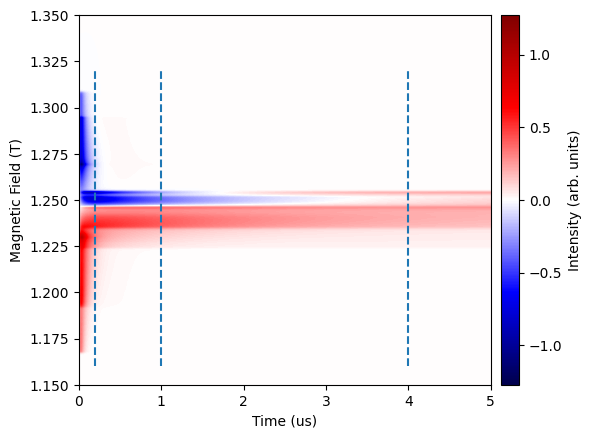

In [76]:
sections_t = [0.2, 1.0, 4.0]

visualization.plot_2d_timeresolved(
    fields, time_long, out / out.max(),
    time_unit="us",
)
plt.vlines(sections_t[0], 1.16, 1.32, colors=None, linestyles='dashed', label='', data=None)
plt.vlines(sections_t[1], 1.16, 1.32, colors=None, linestyles='dashed', label='', data=None)
plt.vlines(sections_t[2], 1.16, 1.32, colors=None, linestyles='dashed', label='', data=None)

plt.savefig("2D_spctrum.eps")

Let's additionally plot the cross-sections at different time moments

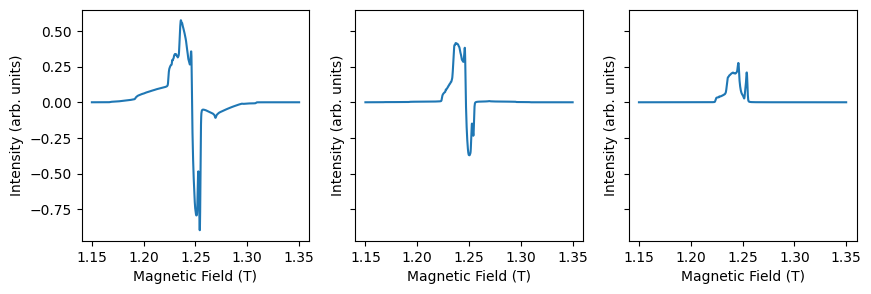

In [88]:
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(10, 3))

for i, t in enumerate(sections_t):
    plt_time = t * 1e-6
    fig.sca(axes[i])  # Set current axes
    
    visualization.plot_field_dependence(
        plt_time,
        fields, time_long, out / out.max(),
    )
plt.savefig("cross_sections.eps")

# 4. Parameter Analysis

Let's unalyze the dependance of the reults and rates on the different experemntal parameters, as wekl as on the orientations

### 4.1 Temperature dependence

We now analyse how the relaxation dynamics depend on temperature. For each temperature, we rebuild the intra‑triplet context (since the spectral density depends on temperature) and compute the time‑resolved spectrum. We then extract the kinetics at two selected field positions.


The temperature dependance follows from 2 factors:

1) Intra‑triplet relaxation – the spectral density J(w) depends on temperature via the Bose–Einstein occupation. This affects the Redfield rates among the triplet sublevels.


2) Reverse intersystem crossing (rISC) – the rates for singlet–triplet exchange (and triplet–triplet exchange)  have a strong temperature dependence and this dependacne forced by detailed balance


In the analysis loop, for each temperature we:

1) Rebuild intra‑triplet contexts

2. Combine each with its respective decay context.

3. Concatenate the triplet CT, triplet LE, and singlet contexts (block‑diagonal).

4. Add the exchange contexts (singlet–triplet and CT–LE triplet exchange) which are independent of temperature in this model.

5. Compute the time‑resolved spectrum for the full 7‑level system.

In [27]:
temperatures = [100, 120, 150, 180, 200, 220, 250, 300]
results = []   # will store (kinetics at field1, kinetics at field2) for each temp

for temp in temperatures:
    # --- Rebuild intra‑triplet contexts for both CT and LE ---
    ctx_ct_intra = get_context_triplet_intra(frequencies, triplet_ct)
    ctx_le_intra = get_context_triplet_intra(frequencies, triplet_le)

    # Combine with decays (decay rates are temperature‑independent)
    ctx_ct_total = ctx_ct_intra + ctx_ct_decay
    ctx_le_total = ctx_le_intra + ctx_le_decay

    # Concatenate the three subsystems (CT, LE, singlet) into one context
    block_ctx = mars.concat((ctx_ct_total, ctx_le_total, ctx_singlet))

    # Add exchange contexts (singlet–triplet and CT–LE triplet exchange)
    final_relax = block_ctx + exch_singlet + exch_triplet

    # Create the spectrum generator for the full sample
    spec_creator = spectra_manager.CoupledTimeSpectra(
        freq=freq_res,
        sample=full_sample,
        harmonic=0,
        context=final_relax,
        temperature=temp,
        device=device,
        dtype=dtype
    )

    fields = torch.linspace(1.15, 1.35, 1000, dtype=dtype, device=device)
    time_long = torch.linspace(0.0, 5e-6, 900, dtype=dtype, device=device)   # 5 us

    out = spec_creator(full_sample, fields=fields, time=time_long)

    # Select two field points (e.g., peaks corresponding to CT and LE)
    idx_1 = torch.argmin((fields - 1.2505).abs())
    idx_2 = torch.argmin((fields - 1.225).abs())
    kin_1 = out[..., idx_1]
    kin_2 = out[..., idx_2]
    results.append((kin_1, kin_2))

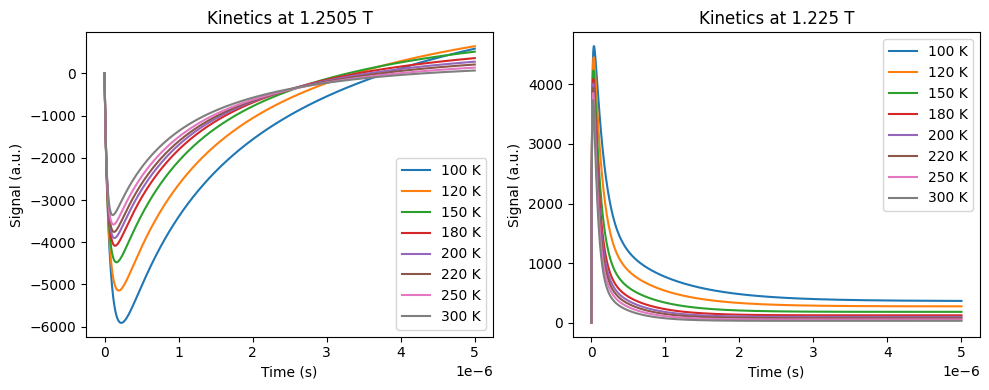

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

for i, (kin1, kin2) in enumerate(results):
    ax1.plot(time_long, kin1, label=f"{temperatures[i]} K")
    ax2.plot(time_long, kin2, label=f"{temperatures[i]} K")

for ax, title in zip((ax1, ax2), ["Kinetics at 1.2505 T", "Kinetics at 1.225 T"]):
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Signal (a.u.)")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

### 4.2 Orientational dependence of intra-triplet relxation

The previous description incorrectly focused on the full 7‑level system. For this analysis, we are only consider  the intra‑triplet relaxation rates of one triplet sublevel (e.g., the CT triplet) as a function of molecular orientation. 
The steps are:

1. For each Euler angle φ (rotation about the z‑axis), build the CT triplet sample with that orientation.

2. Rebuild the intra‑triplet Redfield context for that triplet (using the temperature‑fixed spectral density at 150 K).

3. Diagonalise the triplet Hamiltonian at a fixed field (e.g., 1.24 T) to obtain the eigenstates.

4. Transform the Redfield rate matrix to the eigenbasis and extract the rates (transitions between the three triplet sublevels).

5. Plot these rates as a function of the Euler angle.

In [29]:
# Orientation scan: intra‑triplet rates for the CT triplet
angles = [(0.0, i * math.pi / 99, 0.0) for i in range(100)]
angles_plt = [i * 180.0 / 99 for i in range(100)]   # degrees

tot_rates = []   # each element will be the 3×3 rate matrix in eigenbasis

for angle_tup in angles:
    euler_angles = torch.tensor(angle_tup, dtype=dtype, device=device)
    mesh = mesher.CrystalMesh(euler_angles=euler_angles, dtype=dtype, device=device)

    # Build only the CT triplet sample for this orientation
    # (we can reuse the get_samples function, but we only need the CT part)
    singlet, triplet_le, triplet_ct, _ = get_samples(mesh)   # unpack only what we need

    # Rebuild intra‑triplet context for the CT triplet
    ctx_ct_intra = get_context_triplet_intra(frequencies, triplet_ct)

    # Diagonalise the CT triplet Hamiltonian at B = 1.24 T
    fields = torch.tensor([1.24], dtype=dtype, device=device)
    F, _, _, Gz = triplet_ct.get_hamiltonian_terms()
    H = F + Gz * fields
    H = H.unsqueeze(-3)
    energies, eigen_vectors = torch.linalg.eigh(H)

    # Get the driven (Redfield) rate matrix in the eigenbasis
    rates_intra = ctx_ct_intra.get_transformed_driven_rates(
        eigen_vectors,
        fields=fields.unsqueeze(-2),
        energies=energies,
        temperature=temperature
    )
    # rates_intra is (n_orient, n_field, 3, 3) – we take the first orientation and field
    tot_rates.append(rates_intra[0, 0])   # 3×3 rate matrix


D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\spin_model.py:269: UserWarning: You are creating a block-diagonal (non-interacting) composite spin system via direct sum. This does NOT represent a true multi-particle quantum system (which would require a tensor-product space). Only use this if you are modeling effectively isolated subsystems (e.g., for polarized or time-resolved EPR). For physical spin clusters (diradicals, etc.), build a single SpinSystem with explicit couplings instead.
  concatenated_spin_system = concat_spin_systems(spin_systems)
D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\spin_model.py:2360: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  width = torch.tensor(width, device=device, dtype=dtype)


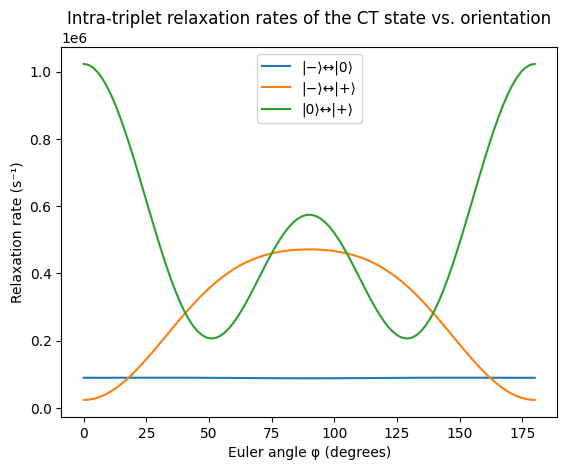

In [30]:
# Extract specific transition rates (off‑diagonal elements)
w_min_zero = [r[1, 0] for r in tot_rates]
w_min_plus = [r[2, 0] for r in tot_rates]
w_zero_plus = [r[2, 1] for r in tot_rates]

plt.plot(angles_plt, w_min_zero, label="|−⟩↔|0⟩")
plt.plot(angles_plt, w_min_plus, label="|−⟩↔|+⟩")
plt.plot(angles_plt, w_zero_plus, label="|0⟩↔|+⟩")
plt.xlabel("Euler angle φ (degrees)")
plt.ylabel("Relaxation rate (s⁻¹)")
plt.legend()
plt.title("Intra‑triplet relaxation rates of the CT state vs. orientation")
plt.show()

The plotted rates show a strong orientation dependence for all three transitions. The magnitudes and angular profiles differ significantly:

- The $|-1\rangle \leftrightarrow |+1\rangle$ and $|0\rangle \leftrightarrow |+1\rangle$ transitions display large variations (up to an order of magnitude) over the 0–180° range.

- The $|-1\rangle \leftrightarrow |0\rangle$ transition also exhibits an orientation dependence, but its rates are consistently smaller than the others, making its variation less prominent on the same vertical scale.